# Sequence Inspector

Sanity-checks every `.npz` file in `processed/sequences/` across four sections:

1. **Corpus overview** — file count, schema version split  
2. **Per-file scalar checks** — shape, NaN, `times` monotonicity & cadence, scalar consistency  
3. **Distribution plots** — `n_windows`, cadence spacing, TBJD range by sector, flux IQR  
4. **Detailed view** — reconstructed segment + zoomed window with real time axis

**NPZ schema** (current):  
`windows (N,1024,1)` · `times (N,1024)` · `tic_id` · `sector` · `seg_idx` · `run_idx` · `n_windows`  
Files missing `times` or `run_idx` are old-schema and flagged for regeneration.

In [47]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
SEQ_DIR           = Path("../../processed/sequences")
T                 = 1024              # window length (cadences)
STRIDE            = 1024              # stride used when building windows
SEED              = 11

CADENCE_DAYS      = 2 / 1440          # 2-min cadence in days (~0.001389)
CADENCE_TOL       = 3 * CADENCE_DAYS  # max allowed cross-window gap before flagging
TBJD_MIN          = 1000.0            # pathological lower bound (pre-TESS era)
TBJD_MAX          = 6000.0            # pathological upper bound

# ── Corpus ────────────────────────────────────────────────────────────────────
all_files = sorted(SEQ_DIR.glob("**/*.npz"))
print(f"Total .npz files found: {len(all_files)}")

Total .npz files found: 1008


## Section 1 — Corpus overview & schema version split

In [48]:
old_schema, new_schema = [], []

for p in all_files:
    try:
        keys = np.load(p, allow_pickle=True).files
    except Exception:
        old_schema.append(p)
        continue
    if "times" in keys and "run_idx" in keys:
        new_schema.append(p)
    else:
        old_schema.append(p)

print(f"Current-schema files (have times + run_idx): {len(new_schema)}")
print(f"Old-schema files (missing times or run_idx):  {len(old_schema)}")
if old_schema:
    print("  Old-schema files need regeneration:")
    for p in old_schema[:10]:
        print(f"    {p.name}")
    if len(old_schema) > 10:
        print(f"    ... and {len(old_schema) - 10} more")

Current-schema files (have times + run_idx): 1008
Old-schema files (missing times or run_idx):  0


## Section 2 — Per-file scalar checks

Scans every current-schema file and records:

| Check | Pass condition |
|---|---|
| `windows` shape | `(N, 1024, 1)` with N ≥ 4 |
| `windows` NaN count | must be 0 (Class-A guarantee) |
| `windows` flux range | `abs(max) ≤ 20` after MAD-norm |
| `times` shape | `(N, 1024)` — parallel to windows |
| `times` TBJD range | `1000 ≤ times ≤ 6000` |
| `times` row monotonicity | each row strictly increasing |
| `times` cross-window gap | `times[i+1,0] - times[i,-1]` within 3× cadence |
| `n_windows` consistency | scalar equals `windows.shape[0]` |

In [49]:
def check_file(p: Path) -> dict:
    row: dict = {"file": p.name, "ok": True}
    flags: list[str] = []

    try:
        d = np.load(p, allow_pickle=True)
    except Exception as e:
        row["ok"] = False
        row["flags"] = f"load_error:{e}"
        return row

    windows = d["windows"]          # expected (N, 1024, 1)
    times   = d["times"]            # expected (N, 1024)
    n_win_scalar = int(d["n_windows"])

    N = windows.shape[0]
    row["n_windows"] = N
    row["sector"]    = int(d["sector"])
    row["tic_id"]    = int(d["tic_id"])

    # --- windows shape ---
    if windows.ndim != 3 or windows.shape[1] != T or windows.shape[2] != 1:
        flags.append(f"windows_shape:{windows.shape}")
    if N < 4:
        flags.append(f"n_windows_lt4:{N}")

    # --- windows NaN ---
    nan_count = int(np.isnan(windows).sum())
    row["windows_nan"] = nan_count
    if nan_count > 0:
        flags.append(f"windows_has_nan:{nan_count}")

    # --- windows flux range ---
    flux_absmax = float(np.nanmax(np.abs(windows)))
    row["flux_absmax"] = round(flux_absmax, 3)
    if flux_absmax > 20:
        flags.append(f"flux_absmax:{flux_absmax:.2f}")

    # --- times shape ---
    if times.ndim != 2 or times.shape[0] != N or times.shape[1] != T:
        flags.append(f"times_shape:{times.shape}")

    # --- times TBJD range ---
    t_min, t_max = float(times.min()), float(times.max())
    row["tbjd_min"] = round(t_min, 3)
    row["tbjd_max"] = round(t_max, 3)
    if t_min < TBJD_MIN:
        flags.append(f"tbjd_too_low:{t_min:.2f}")
    if t_max > TBJD_MAX:
        flags.append(f"tbjd_too_high:{t_max:.2f}")

    # --- times row monotonicity ---
    non_mono_rows = int(np.sum(np.any(np.diff(times, axis=1) <= 0, axis=1)))
    row["times_non_mono_rows"] = non_mono_rows
    if non_mono_rows > 0:
        flags.append(f"times_not_monotone_rows:{non_mono_rows}")

    # --- times cross-window gap ---
    # gap between end of window i and start of window i+1
    if N > 1:
        gaps = times[1:, 0] - times[:-1, -1]   # shape (N-1,)
        row["cadence_median_days"] = round(float(np.median(np.diff(times[0]))), 6)
        bad_gaps = int(np.sum(gaps > CADENCE_TOL))
        row["cross_window_bad_gaps"] = bad_gaps
        if bad_gaps > 0:
            flags.append(f"cross_window_gap:{bad_gaps}")
    else:
        row["cadence_median_days"] = round(float(np.median(np.diff(times[0]))), 6)
        row["cross_window_bad_gaps"] = 0

    # --- n_windows scalar consistency ---
    if n_win_scalar != N:
        flags.append(f"n_windows_mismatch:scalar={n_win_scalar},actual={N}")

    if flags:
        row["ok"] = False
        row["flags"] = "; ".join(flags)
    else:
        row["flags"] = ""

    return row


print("Running checks on all current-schema files...")
records = [check_file(p) for p in new_schema]
df_checks = pd.DataFrame(records)

n_ok  = df_checks["ok"].sum()
n_bad = (~df_checks["ok"]).sum()
print(f"\nPassed: {n_ok} / {len(df_checks)}   Failed: {n_bad}")

if n_bad > 0:
    print("\nFailed files:")
    display(df_checks[~df_checks["ok"]][["file", "sector", "n_windows", "flags"]])
else:
    print("All files passed every check.")

Running checks on all current-schema files...

Passed: 998 / 1008   Failed: 10

Failed files:


,file,sector,n_windows,flags
107,TIC0071847068_s85_seg155_run00.npz,85,4,flux_absmax:31.27
355,TIC0275259749_s59_seg09_run00.npz,59,4,flux_absmax:48.83
539,TIC0348517784_s85_seg176_run00.npz,85,4,flux_absmax:68.24
616,TIC0372131402_s57_seg09_run00.npz,57,4,flux_absmax:59.37
715,TIC0399947158_s71_seg26_run00.npz,71,4,flux_absmax:53.27
911,TIC0444335503_s57_seg12_run00.npz,57,5,flux_absmax:29.94
912,TIC0444335503_s58_seg00_run00.npz,58,4,flux_absmax:23.65
913,TIC0444335503_s78_seg05_run00.npz,78,4,flux_absmax:21.46
914,TIC0444335503_s85_seg117_run00.npz,85,4,flux_absmax:25.31
979,TIC0611978188_s57_seg09_run00.npz,57,4,flux_absmax:59.37


## Section 3 — Distribution plots

Four panels from `df_checks` (current-schema files only):

- **n_windows per file** — distribution of how many Class-A windows each file contains  
- **Cadence spacing** — median within-window cadence; should be a sharp peak at ~0.00139 days (2 min)  
- **TBJD range by sector** — `tbjd_min` scatter coloured by sector; verifies sector-correlated timestamps  
- **Flux abs-max** — distribution of `flux_absmax`; values > 5 are unusual after MAD-norm

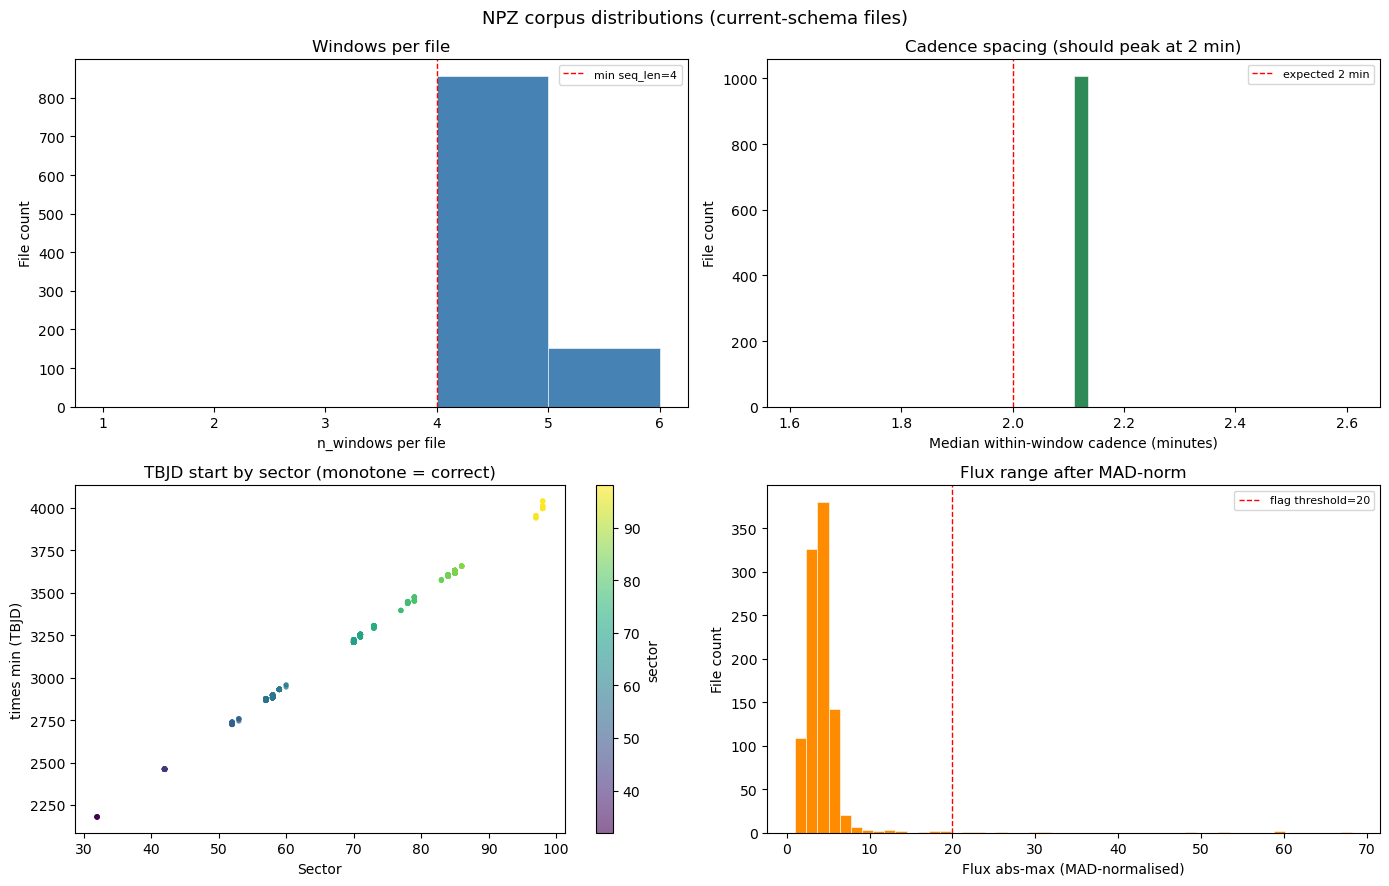


Summary statistics (current-schema files):


,n_windows,cadence_median_days,tbjd_min,tbjd_max,flux_absmax,windows_nan,cross_window_bad_gaps
count,1008.0000,1008.0000,1008.0000,1008.0000,1008.0000,1008.0,1008.0
mean,4.1498,0.0015,3208.6025,3214.5031,4.4084,0.0,0.0
std,0.3571,0.0000,376.8238,376.6621,4.4833,0.0,0.0
min,4.0000,0.0015,2179.4970,2185.1840,1.0230,0.0,0.0
25%,4.0000,0.0015,2882.3350,2888.0230,3.1322,0.0,0.0
50%,4.0000,0.0015,3221.6710,3227.3580,3.9040,0.0,0.0
75%,4.0000,0.0015,3604.1970,3609.8840,4.7785,0.0,0.0
max,5.0000,0.0015,4038.8560,4044.5430,68.2420,0.0,0.0


In [50]:
if df_checks.empty:
    print("No current-schema files to plot.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("NPZ corpus distributions (current-schema files)", fontsize=13)

    # ── 1. n_windows per file ────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.hist(df_checks["n_windows"], bins=range(1, int(df_checks["n_windows"].max()) + 2),
            color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(4, color="red", linestyle="--", linewidth=1, label="min seq_len=4")
    ax.set_xlabel("n_windows per file")
    ax.set_ylabel("File count")
    ax.set_title("Windows per file")
    ax.legend(fontsize=8)

    # ── 2. Cadence spacing ───────────────────────────────────────────────────
    ax = axes[0, 1]
    cad = df_checks["cadence_median_days"].dropna()
    ax.hist(cad * 1440, bins=40, color="seagreen", edgecolor="white", linewidth=0.4)
    ax.axvline(2.0, color="red", linestyle="--", linewidth=1, label="expected 2 min")
    ax.set_xlabel("Median within-window cadence (minutes)")
    ax.set_ylabel("File count")
    ax.set_title("Cadence spacing (should peak at 2 min)")
    ax.legend(fontsize=8)

    # ── 3. TBJD range by sector ──────────────────────────────────────────────
    ax = axes[1, 0]
    sc = ax.scatter(
        df_checks["sector"], df_checks["tbjd_min"],
        c=df_checks["sector"], cmap="viridis", s=8, alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label="sector")
    ax.set_xlabel("Sector")
    ax.set_ylabel("times min (TBJD)")
    ax.set_title("TBJD start by sector (monotone = correct)")

    # ── 4. Flux abs-max ──────────────────────────────────────────────────────
    ax = axes[1, 1]
    ax.hist(df_checks["flux_absmax"], bins=50, color="darkorange", edgecolor="white", linewidth=0.4)
    ax.axvline(20, color="red", linestyle="--", linewidth=1, label="flag threshold=20")
    ax.set_xlabel("Flux abs-max (MAD-normalised)")
    ax.set_ylabel("File count")
    ax.set_title("Flux range after MAD-norm")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Summary stats table
    cols = ["n_windows", "cadence_median_days", "tbjd_min", "tbjd_max", "flux_absmax",
            "windows_nan", "cross_window_bad_gaps"]
    print("\nSummary statistics (current-schema files):")
    display(df_checks[cols].describe().round(4))

## Section 4 — Detailed view (flux + time axis)

Randomly samples `N_SAMPLE` files and plots:
- **Top**: reconstructed segment on the real TBJD time axis, with the selected window highlighted  
- **Bottom**: zoomed view of that window; x-axis is real TBJD, not cadence offset

TIC 306956595  sector=58  seg=27  n_windows=4  showing window 0


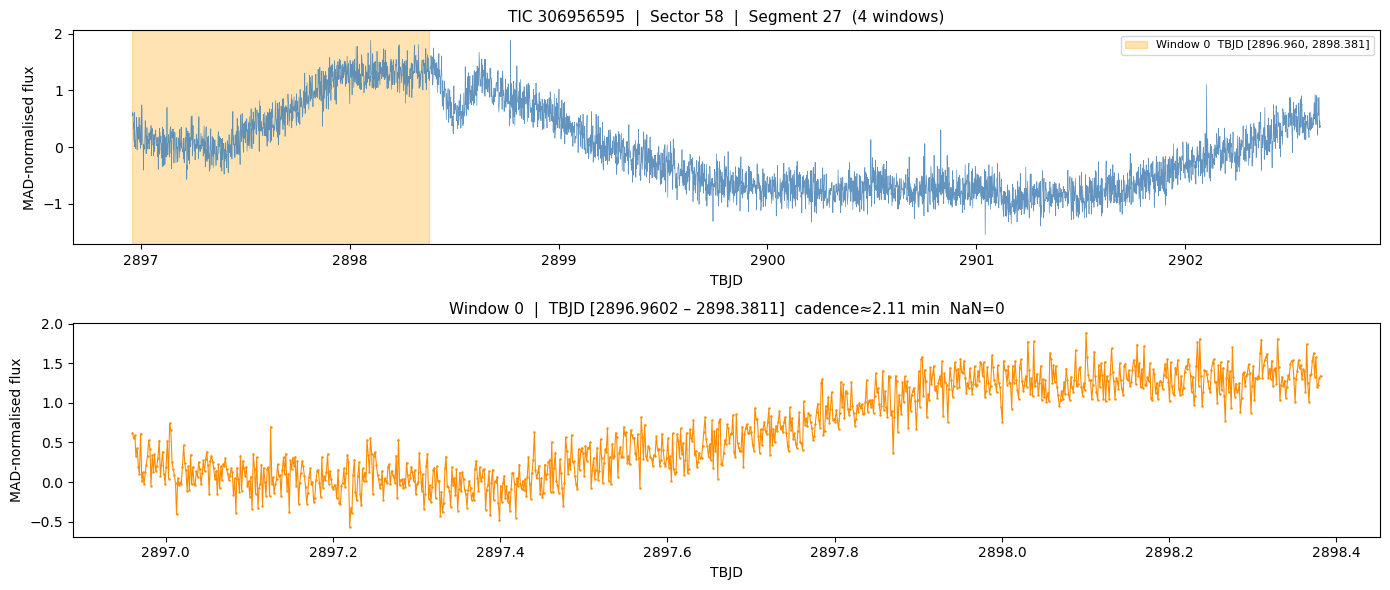

TIC 436933294  sector=70  seg=0  n_windows=4  showing window 0


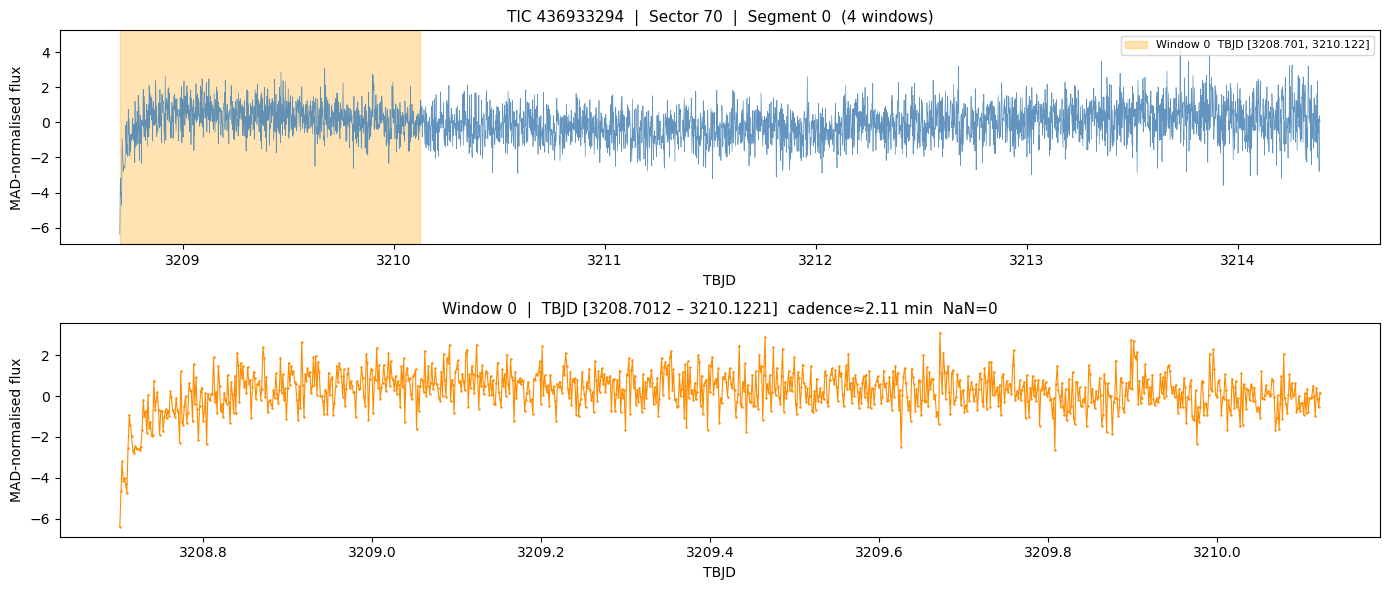

TIC 354842480  sector=52  seg=11  n_windows=4  showing window 0


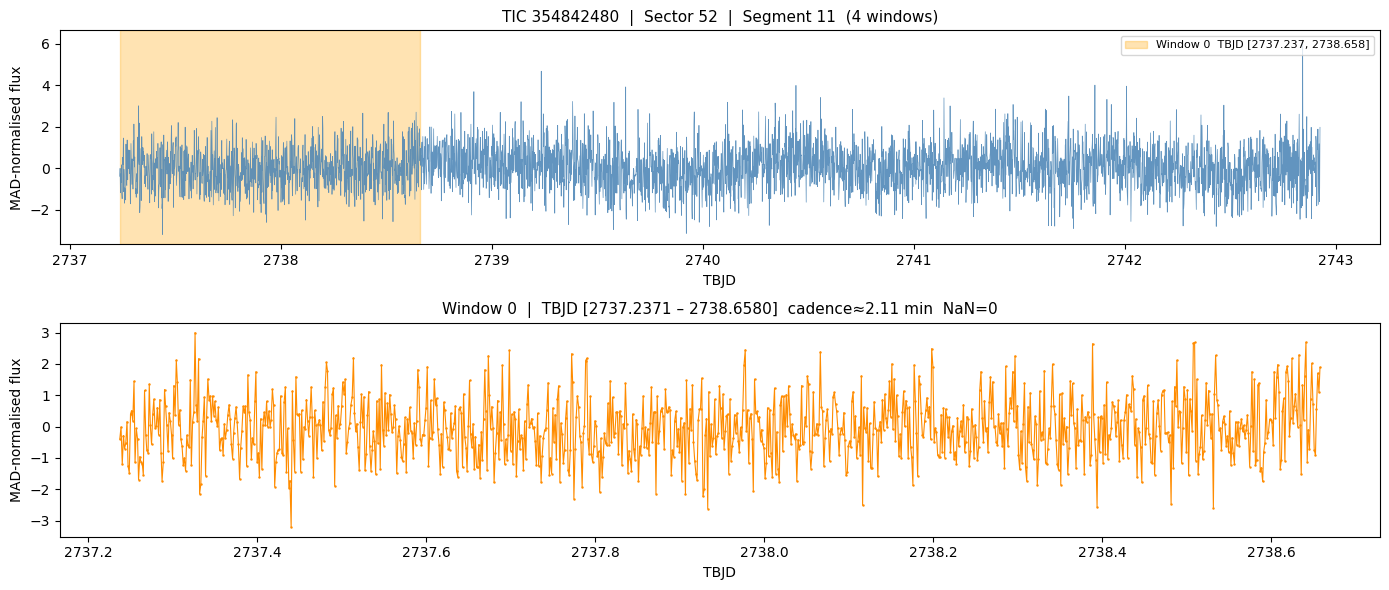

In [51]:
N_SAMPLE   = 3    # number of files to inspect visually
WINDOW_IDX = 0    # which window to highlight; clipped to [0, n_windows-1]

rng          = random.Random(SEED)
sample_files = rng.sample(new_schema or all_files, min(N_SAMPLE, len(new_schema or all_files)))


def reconstruct_segment_timed(
    windows: np.ndarray, times: np.ndarray, stride: int
) -> tuple[np.ndarray, np.ndarray]:
    """Stitch windows into an approximate segment using real timestamps.

    windows: (N, T)  flux array (squeezed)
    times:   (N, T)  TBJD array

    Returns (flux_1d, time_1d) of length (N-1)*stride + T.
    Later windows overwrite earlier ones in the overlap zone.
    """
    n, t = windows.shape
    total = (n - 1) * stride + t
    flux_seg = np.full(total, np.nan)
    time_seg = np.full(total, np.nan)
    for i in range(n):
        s = i * stride
        flux_seg[s : s + t] = windows[i]
        time_seg[s : s + t] = times[i]
    return flux_seg, time_seg


def plot_detail(npz_path: Path, window_idx: int = 0) -> None:
    d        = np.load(npz_path, allow_pickle=True)
    windows  = d["windows"].squeeze(-1)              # (N, 1024)
    has_times = "times" in d.files
    times    = d["times"] if has_times else None     # (N, 1024) or None
    tic_id   = int(d["tic_id"])
    sector   = int(d["sector"])
    seg_idx  = int(d["seg_idx"])
    n_win    = windows.shape[0]
    window_idx = min(window_idx, n_win - 1)

    print(
        f"TIC {tic_id}  sector={sector}  seg={seg_idx}  "
        f"n_windows={n_win}  showing window {window_idx}"
    )

    if has_times:
        flux_seg, time_seg = reconstruct_segment_timed(windows, times, STRIDE)
        win_time = times[window_idx]
        x_seg_label = "TBJD"
    else:
        # fallback: cadence offsets (old-schema files)
        total = (n_win - 1) * STRIDE + T
        flux_seg = np.full(total, np.nan)
        for i, w in enumerate(windows):
            flux_seg[i * STRIDE : i * STRIDE + T] = w
        time_seg  = np.arange(total, dtype=float)
        win_time  = time_seg[window_idx * STRIDE : window_idx * STRIDE + T]
        x_seg_label = "Cadence offset (no times key)"

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

    # Top — full reconstructed segment
    axes[0].plot(time_seg, flux_seg, lw=0.5, color="steelblue", alpha=0.85)
    if has_times:
        axes[0].axvspan(
            float(win_time[0]), float(win_time[-1]),
            color="orange", alpha=0.30,
            label=f"Window {window_idx}  TBJD [{win_time[0]:.3f}, {win_time[-1]:.3f}]"
        )
    axes[0].set_title(
        f"TIC {tic_id}  |  Sector {sector}  |  Segment {seg_idx}  ({n_win} windows)",
        fontsize=11
    )
    axes[0].set_ylabel("MAD-normalised flux")
    axes[0].set_xlabel(x_seg_label)
    axes[0].legend(fontsize=8, loc="upper right")

    # Bottom — zoomed window
    win_flux = windows[window_idx]
    nan_ct   = int(np.isnan(win_flux).sum())
    axes[1].plot(win_time, win_flux, lw=0.8, color="darkorange", marker=".", ms=1.5)
    title_extra = (
        f"TBJD [{win_time[0]:.4f} – {win_time[-1]:.4f}]  "
        f"cadence≈{float(np.median(np.diff(win_time))) * 1440:.2f} min  NaN={nan_ct}"
        if has_times else f"length={T}  NaN={nan_ct}"
    )
    axes[1].set_title(f"Window {window_idx}  |  {title_extra}", fontsize=11)
    axes[1].set_ylabel("MAD-normalised flux")
    axes[1].set_xlabel(x_seg_label)

    plt.tight_layout()
    plt.show()


for path in sample_files:
    plot_detail(path, window_idx=WINDOW_IDX)